# Cayley Graphs and Irreducible Representations

Visualizing group structure and spectral basis for:
1. **Cyclic Group** $\mathbb{Z}_{12}$ — Abelian, 12 one-dimensional irreps
2. **Alternating Group** $A_4$ — Non-abelian, 3 one-dimensional + 1 three-dimensional irreps

In [160]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize, LinearSegmentedColormap
from itertools import permutations

# =============================================================================
# Publication-Quality Style Settings - LARGER FONTS
# =============================================================================
plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
    'font.serif': ['Palatino', 'Palatino Linotype', 'P052', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 16,
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.5,
    'figure.facecolor': 'white',
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

# =============================================================================
# Colormap: Blue -> White -> Red
# =============================================================================
blue_white_red = LinearSegmentedColormap.from_list(
    'blue_white_red',
    ['#0D2758', 'white', '#A32015'],
    N=256
)

# =============================================================================
# Unified Color Scheme
# =============================================================================
COLORS = {
    'edge_primary': '#0D2758',    # Deep blue (matches cmap)
    'edge_secondary': '#A32015',  # Deep red (matches cmap)
    'node_fill': 'white',         # White
    'node_edge': '#0D2758',       # Deep blue
    'cmap': blue_white_red,
}

CAYLEY_PARAMS = {
    'node_size': 1100,
    'arrow_size': 11,
    'edge_width': 1.2,
    'node_edge_width': 1.2,
    'font_size': 13,
    'alpha_edge': 0.9,
}

# =============================================================================
# Figure dimensions - EDIT THESE VALUES
# =============================================================================
FIG_WIDTH = 5.0
FIG_HEIGHT = 5.0

## Archived Code (Other Groups)

The following cell contains commented-out code for other group visualizations:
- Frobenius Group $F_{21} = C_7 \rtimes C_3$
- Generic Cyclic Group $\mathbb{Z}_p$  
- Symmetric Group $S_n$

In [161]:
# =============================================================================
# ARCHIVED: Frobenius Group F21, Cyclic Group Z_p, Symmetric Group S_n
# =============================================================================

# # --- Frobenius Group F21 = C7 ⋊ C3 ---
# nodes_f21 = [(a, b) for a in range(7) for b in range(3)]
# G_f21 = nx.DiGraph()
# G_f21.add_nodes_from(nodes_f21)
# for (a, b) in nodes_f21:
#     G_f21.add_edge((a, b), ((a + 1) % 7, b), generator='x')
#     G_f21.add_edge((a, b), ((2 * a) % 7, (b + 1) % 3), generator='y')
# pos_f21 = {}
# for b in range(3):
#     radius = 1.0 + 0.6 * b
#     for a in range(7):
#         angle = 2 * np.pi * a / 7 - np.pi/2
#         pos_f21[(a, b)] = (radius * np.cos(angle), radius * np.sin(angle))

# # --- Cyclic Group Z_p (generic) ---
# p = 17
# G_cyclic = nx.DiGraph()
# G_cyclic.add_nodes_from(range(p))
# for x in range(p):
#     G_cyclic.add_edge(x, (x + 1) % p)
# pos_cyclic = {}
# for x in range(p):
#     angle = 2 * np.pi * x / p - np.pi/2
#     pos_cyclic[x] = (np.cos(angle), np.sin(angle))

# # --- Symmetric Group S_n ---
# def perm_to_cycles(perm):
#     """Convert permutation to cycle notation."""
#     n = len(perm)
#     visited = [False] * n
#     cycles = []
#     for i in range(n):
#         if visited[i]:
#             continue
#         cycle = []
#         j = i
#         while not visited[j]:
#             visited[j] = True
#             cycle.append(j + 1)
#             j = perm[j]
#         if len(cycle) > 1:
#             cycles.append(cycle)
#     if not cycles:
#         return 'Id'
#     cycle_strs = ['(' + '\\,'.join(map(str, c)) + ')' for c in cycles]
#     return r'$' + ''.join(cycle_strs) + r'$'
# 
# n = 4
# elements_sn = list(permutations(range(n)))
# elem_to_idx = {elem: i for i, elem in enumerate(elements_sn)}
# G_sn = nx.DiGraph()
# G_sn.add_nodes_from(range(len(elements_sn)))
# def apply_perm(perm, gen):
#     return tuple(perm[gen[i]] for i in range(n))
# sigma = tuple((i + 1) % n for i in range(n))
# tau = (1, 0) + tuple(range(2, n))
# for perm in elements_sn:
#     idx = elem_to_idx[perm]
#     perm_sigma = apply_perm(perm, sigma)
#     G_sn.add_edge(idx, elem_to_idx[perm_sigma], generator='σ')
#     perm_tau = apply_perm(perm, tau)
#     G_sn.add_edge(idx, elem_to_idx[perm_tau], generator='τ')

pass  # Placeholder to make cell valid

---
## 1. Cyclic Group $\mathbb{Z}_{12}$

The cyclic group of order 12 with generator $r: g \mapsto g + 1 \pmod{12}$.

**Irreducible representations:** 12 one-dimensional irreps $\rho_k(g) = \zeta_{12}^{kg}$ where $\zeta_{12} = e^{2\pi i/12}$.

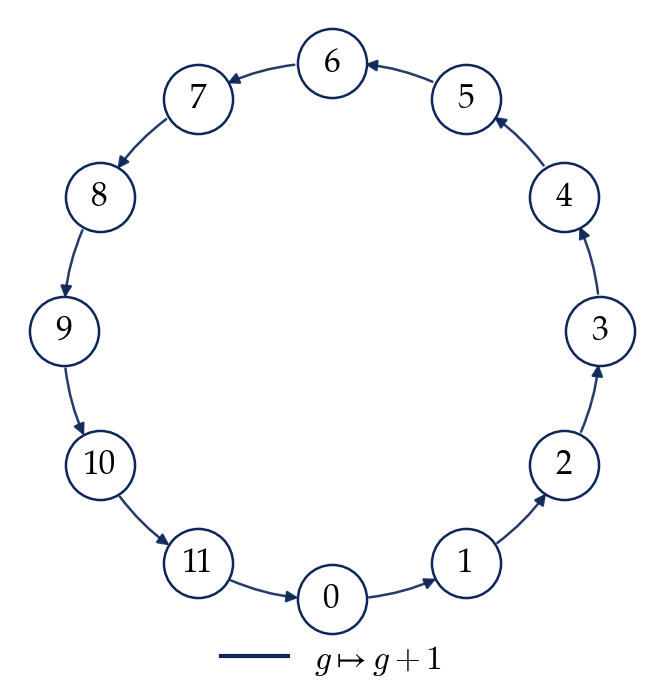

In [162]:
# =============================================================================
# Z12 Cayley Graph
# =============================================================================

N_Z12 = 12

G_z12 = nx.DiGraph()
G_z12.add_nodes_from(range(N_Z12))
for g in range(N_Z12):
    G_z12.add_edge(g, (g + 1) % N_Z12)

pos_z12 = {}
for g in range(N_Z12):
    angle = 2 * np.pi * g / N_Z12 - np.pi/2
    pos_z12[g] = (np.cos(angle), np.sin(angle))

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

nx.draw_networkx_edges(
    G_z12, pos_z12, ax=ax,
    edge_color=COLORS['edge_primary'],
    width=CAYLEY_PARAMS['edge_width'],
    arrows=True, arrowsize=CAYLEY_PARAMS['arrow_size'],
    alpha=CAYLEY_PARAMS['alpha_edge'],
    arrowstyle='-|>', connectionstyle='arc3,rad=0.15',
    min_source_margin=18, min_target_margin=16
)

nx.draw_networkx_nodes(
    G_z12, pos_z12, ax=ax,
    node_color=COLORS['node_fill'],
    node_size=CAYLEY_PARAMS['node_size'],
    edgecolors=COLORS['node_edge'],
    linewidths=CAYLEY_PARAMS['node_edge_width']
)

nx.draw_networkx_labels(
    G_z12, pos_z12, ax=ax,
    font_size=16,
    font_family='serif', font_weight='bold'
)

legend_elements = [
    Line2D([0], [0], color=COLORS['edge_primary'], lw=2, 
           label=r'$g \mapsto g + 1$')
]
ax.legend(handles=legend_elements, loc='lower center', frameon=False,
          bbox_to_anchor=(0.5, -0.08))

ax.axis('off')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('../figures/cayley_Z12.jpg', dpi=300)
plt.show()

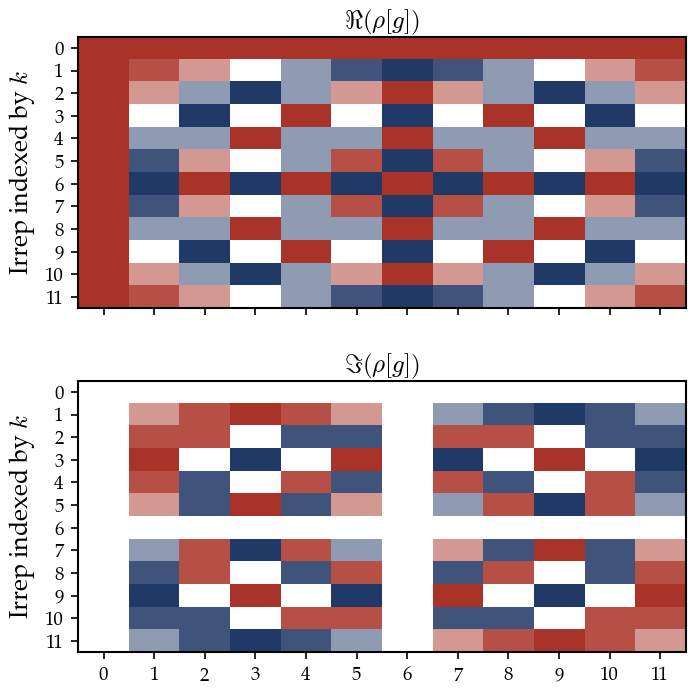

In [180]:
# =============================================================================
# Z12 Spectral Basis (Irreducible Representations)
# =============================================================================

def construct_z12_basis():
    N = 12
    basis = np.zeros((N, N), dtype=complex)
    zeta12 = np.exp(2j * np.pi / N)
    for k in range(N):
        for g in range(N):
            basis[k, g] = (1/np.sqrt(N)) * zeta12**(k * g)
    return basis

basis_z12 = construct_z12_basis()
v_max = np.abs(basis_z12).max() * 1.1
norm_z12 = Normalize(vmin=-v_max, vmax=v_max)

fig, (ax_re, ax_im) = plt.subplots(2, 1, figsize=(FIG_WIDTH, FIG_HEIGHT))

im_re = ax_re.imshow(np.real(basis_z12), cmap=COLORS['cmap'], 
                      norm=norm_z12, interpolation='nearest', aspect='auto')
ax_re.set_ylabel(r'Irrep indexed by $k$', fontsize=12)
ax_re.set_xticks(range(12))
ax_re.set_xticklabels([], fontsize=9)
ax_re.set_yticks(range(12))
ax_re.set_yticklabels([f'{k}' for k in range(12)], fontsize=9)
ax_re.set_title(r'$\Re(\rho[g])$', fontsize=12, pad=2)

im_im = ax_im.imshow(np.imag(basis_z12), cmap=COLORS['cmap'], 
                      norm=norm_z12, interpolation='nearest', aspect='auto')
ax_im.set_ylabel(r'Irrep indexed by $k$', fontsize=12)
ax_im.set_xticks(range(12))
ax_im.set_xticklabels([f'{g}' for g in range(12)], fontsize=9)
ax_im.set_yticks(range(12))
ax_im.set_yticklabels([f'{k}' for k in range(12)], fontsize=9)
ax_im.set_title(r'$\Im(\rho[g])$', fontsize=12, pad=2)

plt.tight_layout()
plt.savefig('../figures/Z12_spectral_basis.jpg', dpi=300)
plt.show()

---
## 2. Alternating Group $A_4$

The alternating group on 4 elements (even permutations), with 12 elements:
- 1 identity
- 8 three-cycles: $(012), (021), (013), (031), (023), (032), (123), (132)$
- 3 double transpositions: $(01)(23), (02)(13), (03)(12)$

**Generators:** $r = (012)$ and $s = (01)(23)$

**Irreducible representations:**
- Three 1D irreps: $\rho_0$ (trivial), $\rho_1$, $\rho_2$ (related to $A_4/V_4 \cong \mathbb{Z}_3$)
- One 3D irrep: $\rho_3$ (standard representation from permutation action)

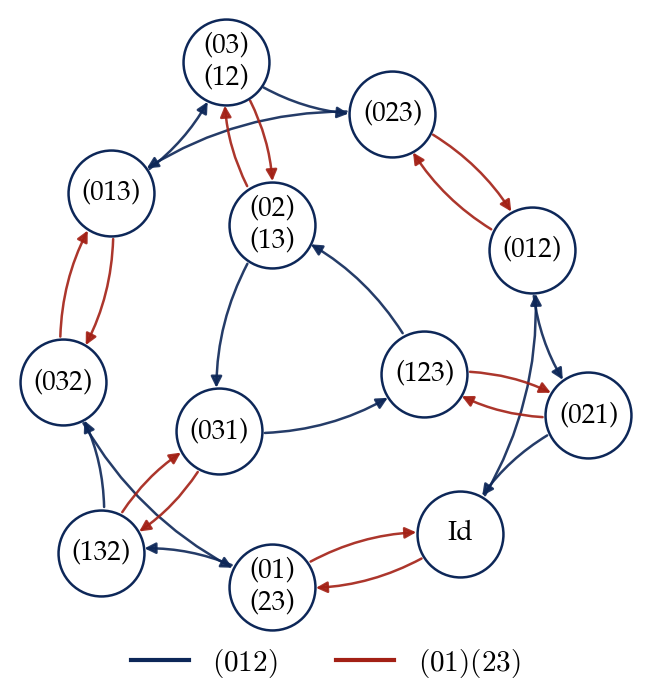

In [164]:
# =============================================================================
# A4 Group Elements and Cayley Graph
# =============================================================================

A4_ELEMENTS = [
    ((0,1,2,3), r"$e$"),           # 0: identity
    ((1,2,0,3), r"$(012)$"),       # 1
    ((2,0,1,3), r"$(021)$"),       # 2
    ((1,3,2,0), r"$(013)$"),       # 3
    ((3,0,2,1), r"$(031)$"),       # 4
    ((2,1,3,0), r"$(023)$"),       # 5
    ((3,1,0,2), r"$(032)$"),       # 6
    ((0,2,3,1), r"$(123)$"),       # 7
    ((0,3,1,2), r"$(132)$"),       # 8
    ((1,0,3,2), r"$(01)(23)$"),    # 9
    ((2,3,0,1), r"$(02)(13)$"),    # 10
    ((3,2,1,0), r"$(03)(12)$"),    # 11
]
A4_PERMS = [e[0] for e in A4_ELEMENTS]
A4_LABELS = [e[1] for e in A4_ELEMENTS]

# Short labels for node display (with line break for double transpositions)
A4_NODE_LABELS = {
    0: 'Id', 1: '(012)', 2: '(021)', 3: '(013)', 4: '(031)', 5: '(023)',
    6: '(032)', 7: '(123)', 8: '(132)', 9: '(01)\n(23)', 10: '(02)\n(13)', 11: '(03)\n(12)'
}

def compose_perm(sigma, tau):
    return tuple(sigma[tau[i]] for i in range(4))

def find_perm_index(perm):
    for i, p in enumerate(A4_PERMS):
        if p == perm:
            return i
    return -1

G_a4 = nx.DiGraph()
G_a4.add_nodes_from(range(12))

gen_r = A4_PERMS[1]
gen_s = A4_PERMS[9]

for i, perm in enumerate(A4_PERMS):
    result_r = compose_perm(perm, gen_r)
    j_r = find_perm_index(result_r)
    G_a4.add_edge(i, j_r, generator='r')
    
    result_s = compose_perm(perm, gen_s)
    j_s = find_perm_index(result_s)
    G_a4.add_edge(i, j_s, generator='s')

pos_a4 = nx.kamada_kawai_layout(G_a4)

edges_r = [(u, v) for u, v, d in G_a4.edges(data=True) if d['generator'] == 'r']
edges_s = [(u, v) for u, v, d in G_a4.edges(data=True) if d['generator'] == 's']

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

nx.draw_networkx_edges(
    G_a4, pos_a4, edgelist=edges_r, ax=ax,
    edge_color=COLORS['edge_primary'],
    width=CAYLEY_PARAMS['edge_width'],
    arrows=True, arrowsize=CAYLEY_PARAMS['arrow_size'],
    alpha=CAYLEY_PARAMS['alpha_edge'],
    arrowstyle='-|>', connectionstyle='arc3,rad=0.2',
    min_source_margin=22, min_target_margin=21
)

nx.draw_networkx_edges(
    G_a4, pos_a4, edgelist=edges_s, ax=ax,
    edge_color=COLORS['edge_secondary'],
    width=CAYLEY_PARAMS['edge_width'],
    arrows=True, arrowsize=CAYLEY_PARAMS['arrow_size'],
    alpha=CAYLEY_PARAMS['alpha_edge'],
    arrowstyle='-|>', connectionstyle='arc3,rad=-0.2',
    min_source_margin=22, min_target_margin=21
)

nx.draw_networkx_nodes(
    G_a4, pos_a4, ax=ax,
    node_color=COLORS['node_fill'],
    node_size=CAYLEY_PARAMS['node_size'] + 600,
    edgecolors=COLORS['node_edge'],
    linewidths=CAYLEY_PARAMS['node_edge_width']
)

# Use cycle notation labels
nx.draw_networkx_labels(
    G_a4, pos_a4, labels=A4_NODE_LABELS, ax=ax,
    font_size=13,
    font_family='serif', font_weight='bold'
)

# Legend with line break for double transposition
legend_elements = [
    Line2D([0], [0], color=COLORS['edge_primary'], lw=2, label=r'$(012)$'),
    Line2D([0], [0], color=COLORS['edge_secondary'], lw=2, label=r'$(01)(23)$')
]
ax.legend(handles=legend_elements, loc='lower center', frameon=False,
          ncol=2, bbox_to_anchor=(0.5, -0.1), fontsize=14)

ax.axis('off')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('../figures/cayley_A4.jpg', dpi=300)
plt.show()

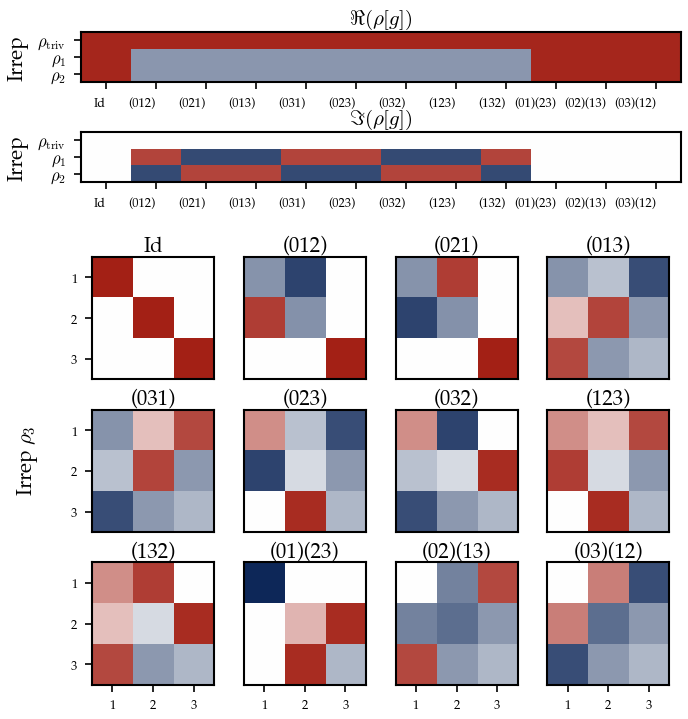


A4 Representation Summary:
Irreps: rho_0 (trivial), rho_1, rho_2 (1D), rho_3 (3D)
Total dimension: 1^2 + 1^2 + 1^2 + 3^2 = 12 = |A_4|


In [181]:
# =============================================================================
# A4 Spectral Basis: Combined 1D and 3D Irreps
# =============================================================================

# Element labels in cycle notation (with line breaks for double transpositions)
A4_CYCLE_LABELS = ['Id', '(012)', '(021)', '(013)', '(031)', '(023)', 
                   '(032)', '(123)', '(132)', '(01)(23)', '(02)(13)', '(03)(12)']

def construct_a4_basis():
    N = 12
    omega = np.exp(2j * np.pi / 3)
    coset_labels = [0, 1, 2, 2, 1, 1, 2, 2, 1, 0, 0, 0]
    
    basis_1d = np.zeros((3, N), dtype=complex)
    norm_1d = 1/np.sqrt(N)
    for g in range(N):
        basis_1d[0, g] = norm_1d * 1
        basis_1d[1, g] = norm_1d * (omega ** coset_labels[g])
        basis_1d[2, g] = norm_1d * (omega ** (2*coset_labels[g]))
    
    v1 = np.array([1, -1, 0, 0]) / np.sqrt(2)
    v2 = np.array([1, 1, -2, 0]) / np.sqrt(6)
    v3 = np.array([1, 1, 1, -3]) / np.sqrt(12)
    V = np.column_stack([v1, v2, v3])
    
    norm_3d = np.sqrt(3/N)
    basis_3d = np.zeros((9, N), dtype=complex)
    
    for g, perm in enumerate(A4_PERMS):
        P = np.zeros((4, 4))
        for i in range(4):
            P[perm[i], i] = 1
        R = V.T @ P @ V
        basis_3d[:, g] = norm_3d * R.flatten()
    
    return basis_1d, basis_3d

basis_1d, basis_3d = construct_a4_basis()

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))

# Define common left/right boundaries so both sections have same width
left_margin = 0.15
right_margin = 0.95

# Top section for 1D irreps
gs_1d = GridSpec(2, 1, figure=fig,
                 left=left_margin, right=right_margin,
                 top=0.95, bottom=0.75,
                 hspace=1)

# Bottom section for 3D irreps (3x4 grid) - tighter spacing
gs_3d = GridSpec(3, 4, figure=fig,
                 left=left_margin, right=right_margin,
                 top=0.65, bottom=0.08,
                 wspace=0.05, hspace=0.25)

v_max_1d = 0.3
norm_1d = Normalize(vmin=-v_max_1d, vmax=v_max_1d)

# 1D irreps: Real part with title
ax_re = fig.add_subplot(gs_1d[0, 0])
ax_re.imshow(np.real(basis_1d), cmap=COLORS['cmap'],
             norm=norm_1d, interpolation='nearest', aspect='auto')
ax_re.set_title(r'$\Re(\rho[g])$', fontsize=10, pad=4)
ax_re.set_ylabel(r'Irrep', fontsize=10)
ax_re.set_xticks(range(12))
ax_re.set_xticklabels(A4_CYCLE_LABELS, fontsize=6, ha='right')
ax_re.set_yticks([0, 1, 2])
ax_re.set_yticklabels([r'$\rho_{\rm triv}$', r'$\rho_1$', r'$\rho_2$'], fontsize=8)

# 1D irreps: Imaginary part with title
ax_im = fig.add_subplot(gs_1d[1, 0])
ax_im.imshow(np.imag(basis_1d), cmap=COLORS['cmap'],
             norm=norm_1d, interpolation='nearest', aspect='auto')
ax_im.set_title(r'$\Im(\rho[g])$', fontsize=10, pad=4)
ax_im.set_ylabel(r'Irrep', fontsize=10)
ax_im.set_xticks(range(12))
ax_im.set_xticklabels(A4_CYCLE_LABELS, fontsize=6, ha='right')
ax_im.set_yticks([0, 1, 2])
ax_im.set_yticklabels([r'$\rho_{\rm triv}$', r'$\rho_1$', r'$\rho_2$'], fontsize=8)

# 3D irrep: 3x4 grid with cycle notation labels
v_max_3d = 0.5
norm_3d = Normalize(vmin=-v_max_3d, vmax=v_max_3d)

# Add label for the entire 3D section on the left
fig.text(0.08, 0.38, r'Irrep $\rho_3$', fontsize=10, rotation=90, va='center', ha='center')

for g in range(12):
    row = g // 4
    col = g % 4
    ax = fig.add_subplot(gs_3d[row, col])
    
    mat_3x3 = np.real(basis_3d[:, g].reshape(3, 3))
    ax.imshow(mat_3x3, cmap=COLORS['cmap'], norm=norm_3d,
              interpolation='nearest', aspect='equal')
    
    # Only outer edges get tick labels
    if row == 2:
        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(['1', '2', '3'], fontsize=6)
    else:
        ax.set_xticks([])
    
    if col == 0:
        ax.set_yticks([0, 1, 2])
        ax.set_yticklabels(['1', '2', '3'], fontsize=6)
    else:
        ax.set_yticks([])
    
    # Use cycle notation as title
    title_labels = ['Id', '(012)', '(021)', '(013)', '(031)', '(023)', 
                    '(032)', '(123)', '(132)', '(01)(23)', '(02)(13)', '(03)(12)']
    ax.set_title(title_labels[g], fontsize=10, pad=2)

# Save with exact figure size (no bbox='tight' expansion)
plt.savefig('../figures/A4_spectral_basis.jpg', dpi=300, bbox_inches=None, pad_inches=0)
plt.show()

print("\nA4 Representation Summary:")
print("Irreps: rho_0 (trivial), rho_1, rho_2 (1D), rho_3 (3D)")
print("Total dimension: 1^2 + 1^2 + 1^2 + 3^2 = 12 = |A_4|")